In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [65]:
df=pd.read_csv("d:\python\dataset\diabetes.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\momin\AppData\Local\Temp\ipykernel_7656\3652857805.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("d:\python\dataset\diabetes.csv")


In [66]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [67]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [68]:
df.ffill (inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.drop_duplicates(inplace=True)

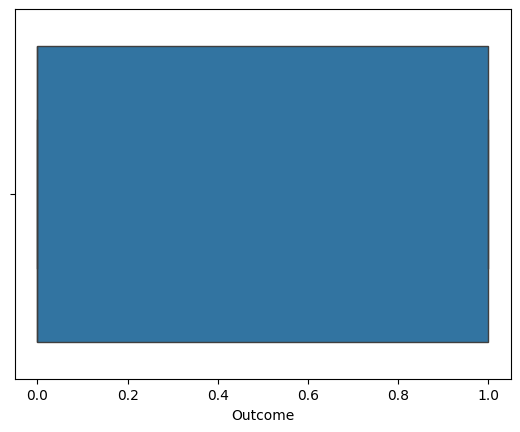

In [71]:
sns.boxplot(x=df['Outcome'])
plt.show()


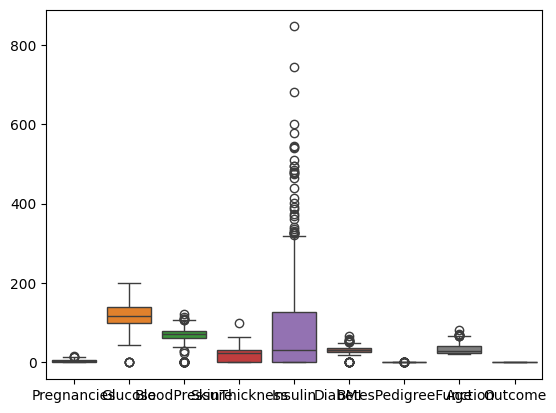

In [72]:
plt.Figure(figsize=(500,500))
sns.boxplot(data=df)
plt.show()

In [ ]:
# Maan lijiye 'df' aapka dataset hai
# Hum sirf numerical columns select karenge (Age, Salary, etc.)
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Ek empty dictionary outliers store karne ke liye
all_outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outliers ko filter karna
    outlier_data = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if not outlier_data.empty:
        all_outliers[col] = len(outlier_data)
        print(f"Column '{col}' mein {len(outlier_data)} outliers mile.")

print("\nSummary of Outliers:", all_outliers)

Column 'Pregnancies' mein 4 outliers mile.
Column 'Glucose' mein 5 outliers mile.
Column 'BloodPressure' mein 45 outliers mile.
Column 'SkinThickness' mein 1 outliers mile.
Column 'Insulin' mein 34 outliers mile.
Column 'BMI' mein 19 outliers mile.
Column 'DiabetesPedigreeFunction' mein 29 outliers mile.
Column 'Age' mein 9 outliers mile.

Summary of Outliers: {'Pregnancies': 4, 'Glucose': 5, 'BloodPressure': 45, 'SkinThickness': 1, 'Insulin': 34, 'BMI': 19, 'DiabetesPedigreeFunction': 29, 'Age': 9}


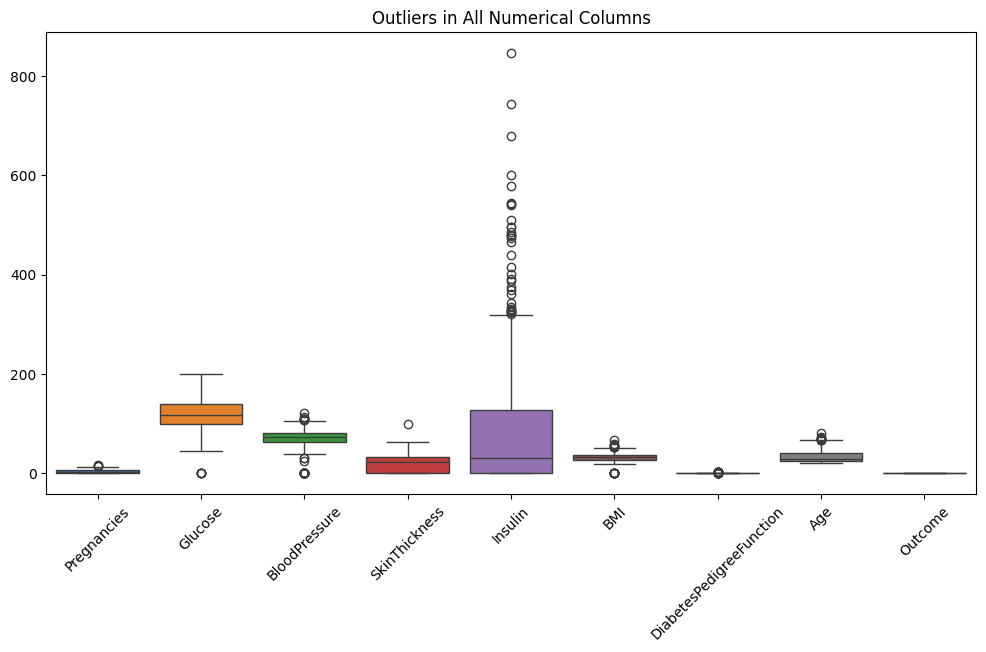

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Saare numerical columns ka boxplot ek hi baar mein
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Outliers in All Numerical Columns")
plt.show()

In [75]:
# IQR filter apply karke clean data nikalna
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sirf wahi data rakhein jo limits ke andar ho
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print("Original Data Shape:", df.shape)
print("Cleaned Data Shape:", df_clean.shape)

Original Data Shape: (768, 9)
Cleaned Data Shape: (636, 9)
